# PM2.5 Temporal Patterns Analysis - Individual Graphs

Generates each temporal analysis graph separately for presentation
All times converted from UTC to JST (UTC+9)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy import signal
import pytz
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

## Load PM2.5 Data and Convert to JST

In [2]:
print("Loading PM2.5 enriched dataset...")
data_path = '/Users/vojtech/Code/Bard89/smoglens-data/pm25_enriched_2023_2025_v4_20250830_222050.csv'

df = pd.read_csv(data_path, 
                 parse_dates=['timestamp'],
                 usecols=['timestamp', 'hex7_id', 'pm25_ugm3_mean', 'temperature_c_mean', 
                         'humidity_pct_mean', 'avg_traffic_volume'])

jst = pytz.timezone('Asia/Tokyo')
df['timestamp_jst'] = df['timestamp'].dt.tz_convert(jst)

df['hour'] = df['timestamp_jst'].dt.hour
df['day_of_week'] = df['timestamp_jst'].dt.dayofweek
df['month'] = df['timestamp_jst'].dt.month
df['year'] = df['timestamp_jst'].dt.year
df['date'] = pd.to_datetime(df['timestamp_jst'].dt.date)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print(f"Loaded {len(df):,} records")
print(f"Date range (JST): {df['timestamp_jst'].min()} to {df['timestamp_jst'].max()}")
print(f"PM2.5 coverage: {df['pm25_ugm3_mean'].notna().mean():.1%}")

Loading PM2.5 enriched dataset...
Loaded 9,457,112 records
Date range (JST): 2023-07-15 01:00:00+09:00 to 2025-07-26 14:00:00+09:00
PM2.5 coverage: 80.5%


## 1. Daily Pattern - 24-Hour Cycle

Saved: graphs/temporal/01_daily_24hour_cycle.png


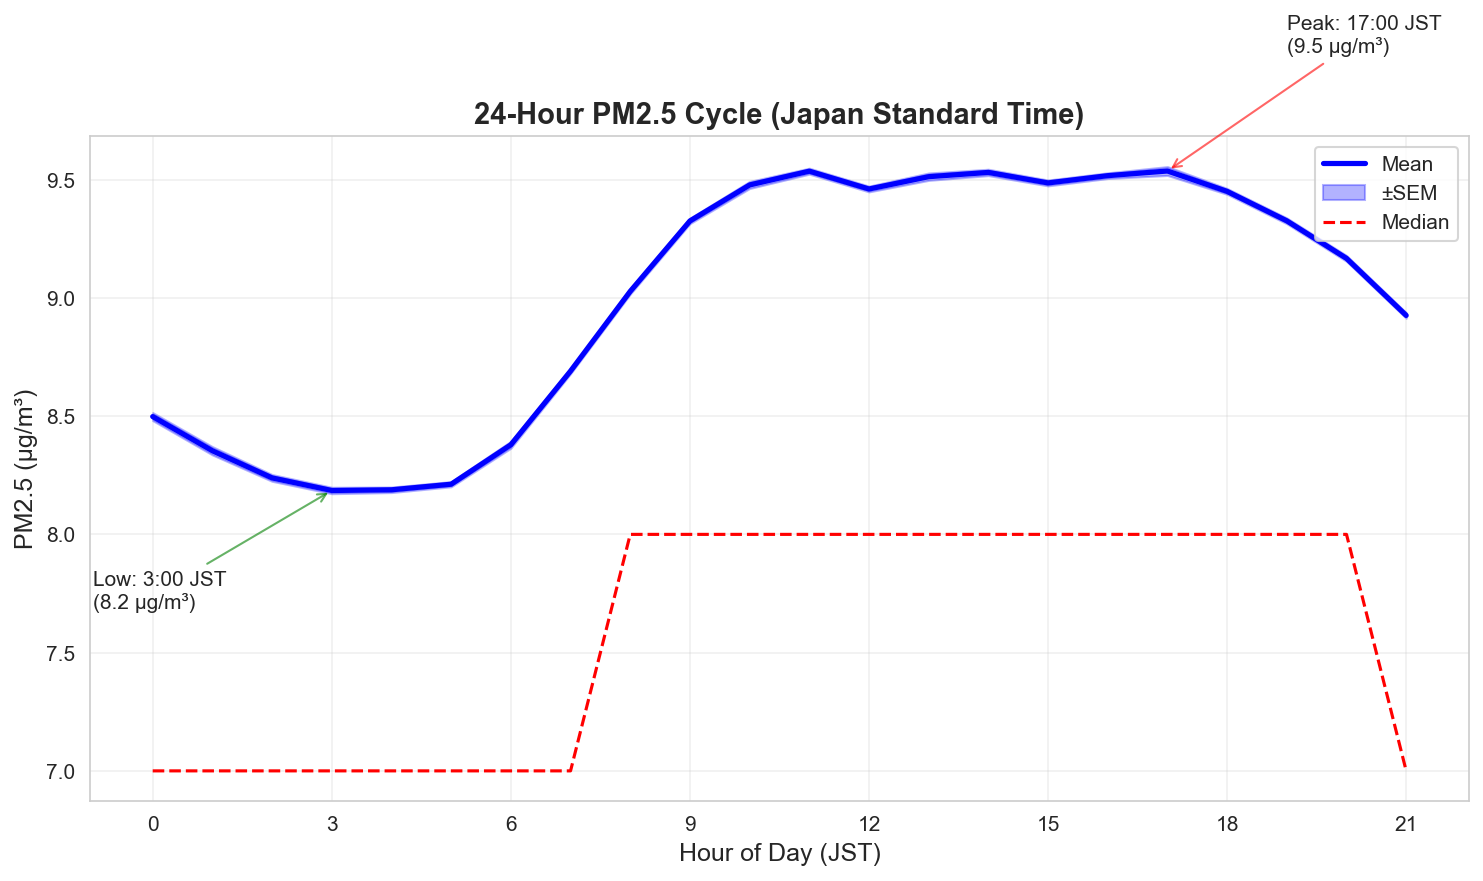

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

hourly_stats = df.groupby('hour')['pm25_ugm3_mean'].agg(['mean', 'std', 'median', 'count'])
hourly_stats['sem'] = hourly_stats['std'] / np.sqrt(hourly_stats['count'])

ax.plot(hourly_stats.index, hourly_stats['mean'], 'b-', linewidth=2.5, label='Mean')
ax.fill_between(hourly_stats.index, 
                hourly_stats['mean'] - hourly_stats['sem'],
                hourly_stats['mean'] + hourly_stats['sem'],
                alpha=0.3, color='blue', label='±SEM')
ax.plot(hourly_stats.index, hourly_stats['median'], 'r--', linewidth=1.5, label='Median')
ax.set_xlabel('Hour of Day (JST)', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('24-Hour PM2.5 Cycle (Japan Standard Time)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24, 3))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

peak_hour = hourly_stats['mean'].idxmax()
low_hour = hourly_stats['mean'].idxmin()
ax.annotate(f'Peak: {peak_hour}:00 JST\n({hourly_stats.loc[peak_hour, "mean"]:.1f} μg/m³)',
           xy=(peak_hour, hourly_stats.loc[peak_hour, 'mean']),
           xytext=(peak_hour+2, hourly_stats.loc[peak_hour, 'mean']+0.5),
           arrowprops=dict(arrowstyle='->', color='red', alpha=0.6))
ax.annotate(f'Low: {low_hour}:00 JST\n({hourly_stats.loc[low_hour, "mean"]:.1f} μg/m³)',
           xy=(low_hour, hourly_stats.loc[low_hour, 'mean']),
           xytext=(low_hour-4, hourly_stats.loc[low_hour, 'mean']-0.5),
           arrowprops=dict(arrowstyle='->', color='green', alpha=0.6))

plt.tight_layout()
plt.savefig('graphs/temporal/01_daily_24hour_cycle.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/01_daily_24hour_cycle.png")
plt.show()

## 2. Weekday vs Weekend Diurnal Pattern

Saved: graphs/temporal/02_weekday_vs_weekend_hourly.png


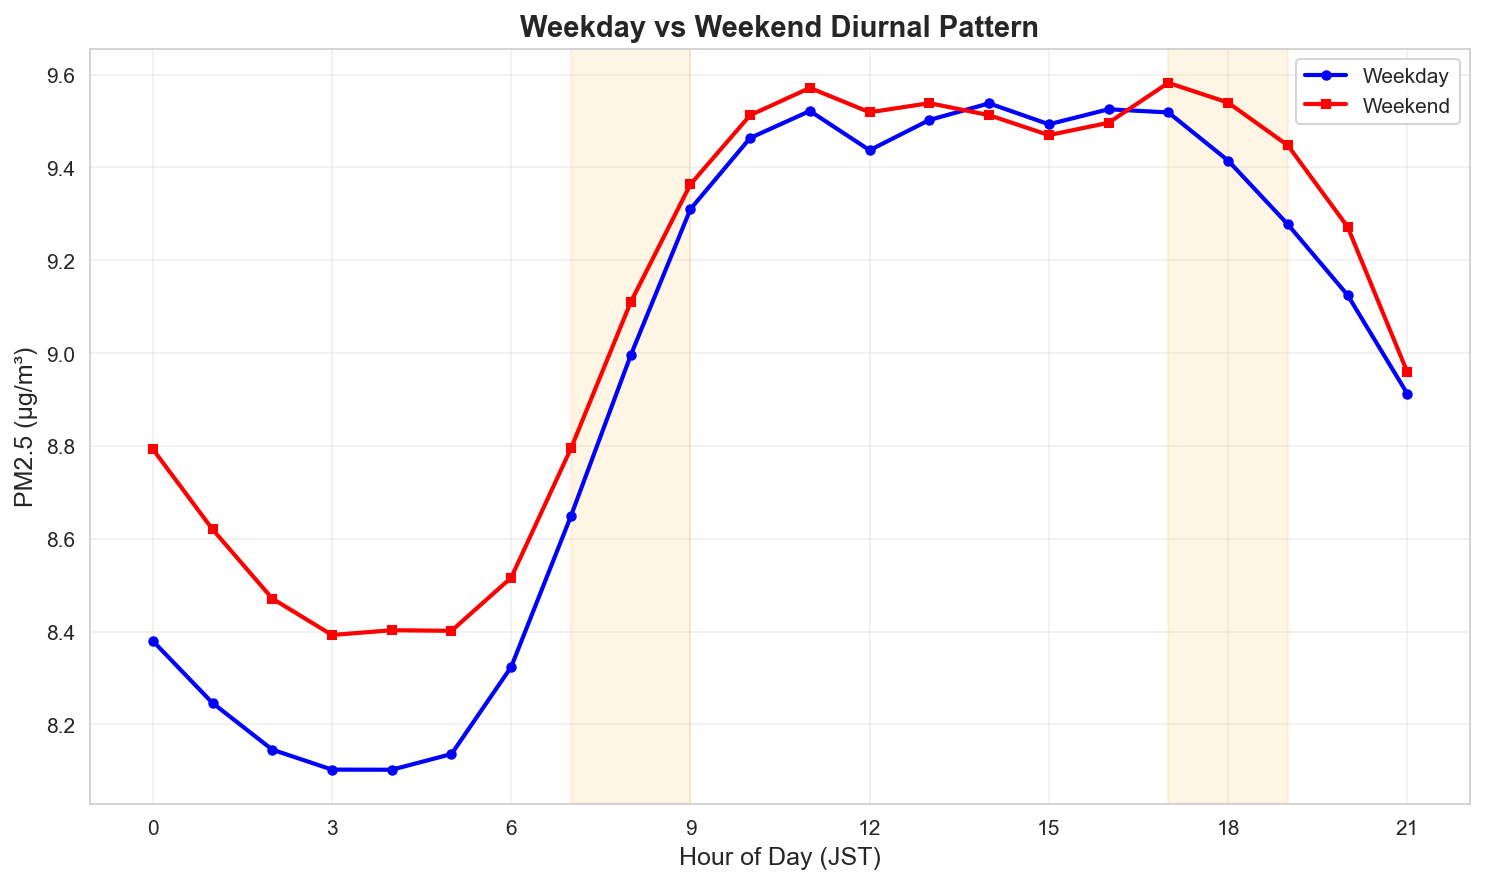

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

weekday_hourly = df[df['is_weekend']==0].groupby('hour')['pm25_ugm3_mean'].mean()
weekend_hourly = df[df['is_weekend']==1].groupby('hour')['pm25_ugm3_mean'].mean()

ax.plot(weekday_hourly.index, weekday_hourly.values, 'b-', linewidth=2, label='Weekday', marker='o', markersize=4)
ax.plot(weekend_hourly.index, weekend_hourly.values, 'r-', linewidth=2, label='Weekend', marker='s', markersize=4)
ax.set_xlabel('Hour of Day (JST)', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('Weekday vs Weekend Diurnal Pattern', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24, 3))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.axvspan(7, 9, alpha=0.1, color='orange', label='Morning rush')
ax.axvspan(17, 19, alpha=0.1, color='orange', label='Evening rush')

plt.tight_layout()
plt.savefig('graphs/temporal/02_weekday_vs_weekend_hourly.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/02_weekday_vs_weekend_hourly.png")
plt.show()

## 3. Diurnal Pattern by Year

Saved: graphs/temporal/03_diurnal_by_year.png


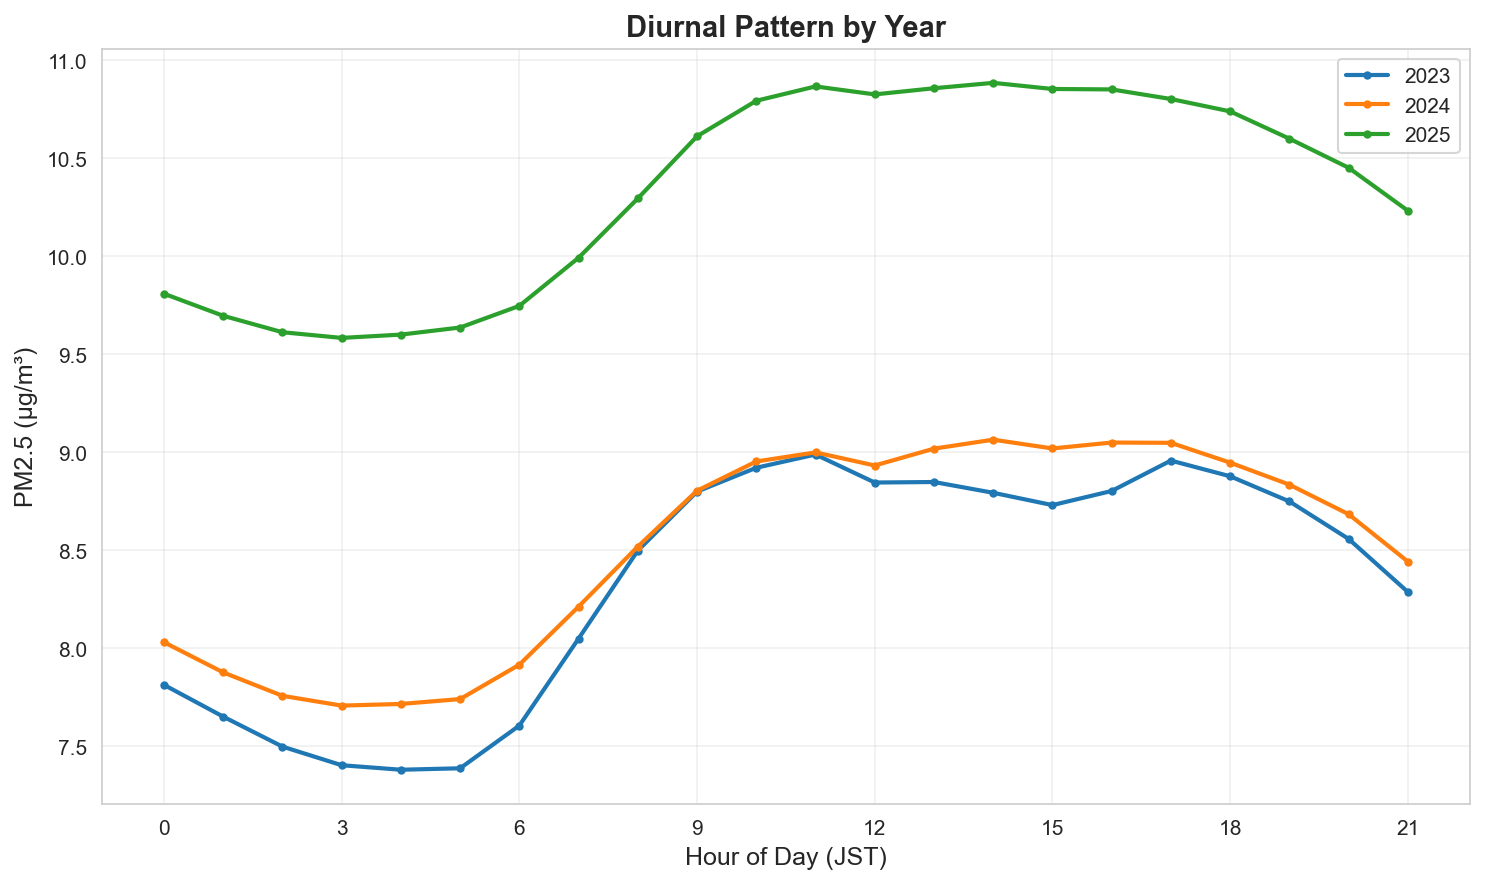

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

hourly_by_year = df.groupby(['year', 'hour'])['pm25_ugm3_mean'].mean().unstack(level=0)
for year in hourly_by_year.columns:
    ax.plot(hourly_by_year.index, hourly_by_year[year], marker='o', markersize=3, label=f'{year}', linewidth=2)

ax.set_xlabel('Hour of Day (JST)', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('Diurnal Pattern by Year', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24, 3))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('graphs/temporal/03_diurnal_by_year.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/03_diurnal_by_year.png")
plt.show()

## 4. PM2.5 vs Traffic Diurnal Patterns

Saved: graphs/temporal/04_pm25_vs_traffic_hourly.png


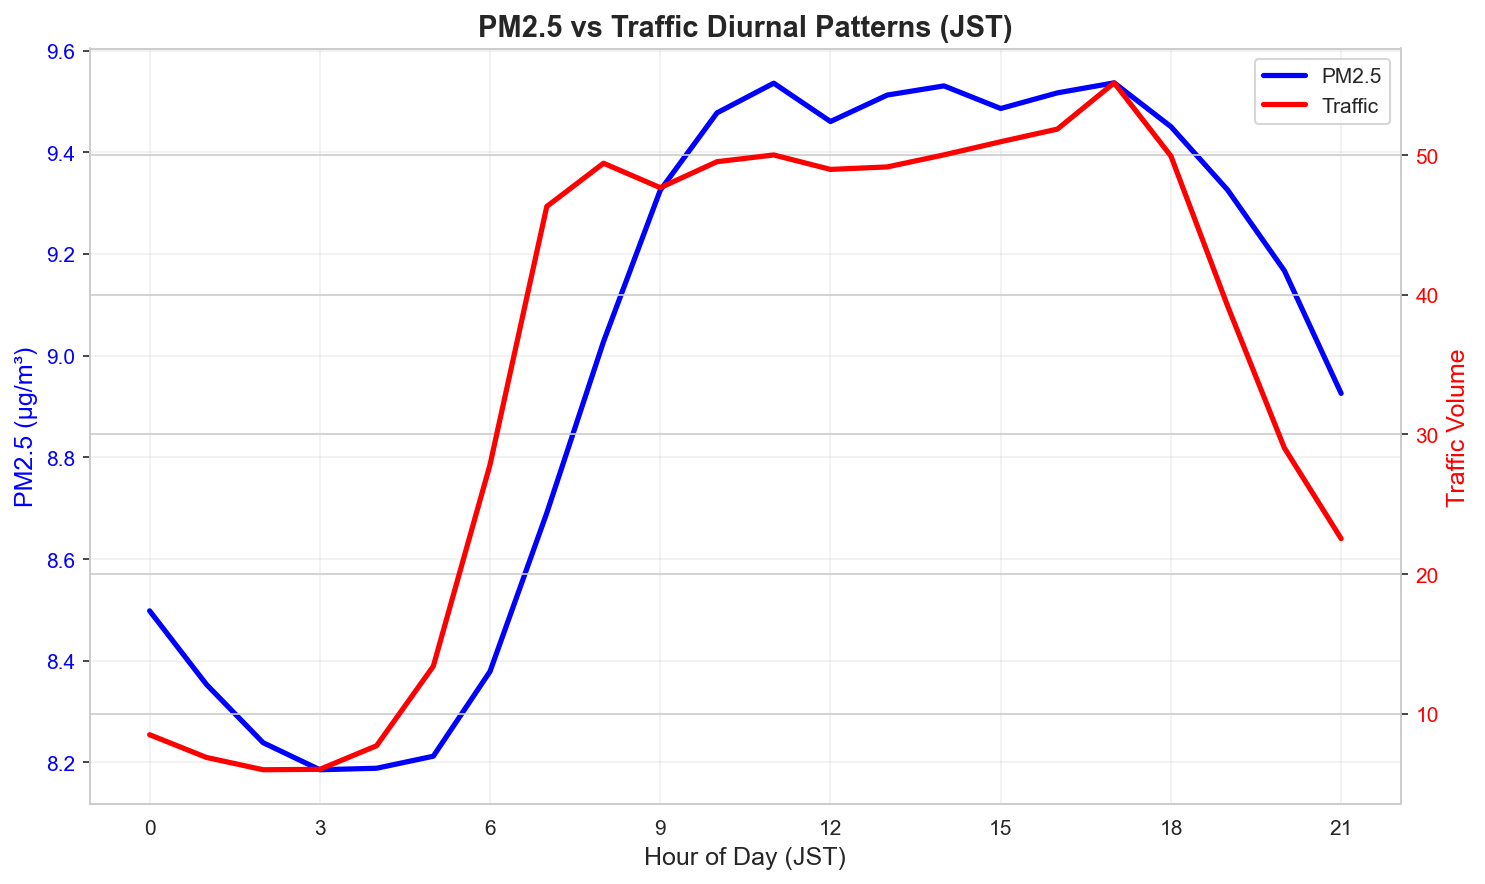

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

hourly_traffic = df.groupby('hour')['avg_traffic_volume'].mean()
hourly_pm25 = df.groupby('hour')['pm25_ugm3_mean'].mean()

ax2 = ax.twinx()
l1 = ax.plot(hourly_pm25.index, hourly_pm25.values, 'b-', linewidth=2.5, label='PM2.5')
l2 = ax2.plot(hourly_traffic.index, hourly_traffic.values, 'r-', linewidth=2.5, label='Traffic')
ax.set_xlabel('Hour of Day (JST)', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', color='b', fontsize=12)
ax2.set_ylabel('Traffic Volume', color='r', fontsize=12)
ax.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')
ax.set_title('PM2.5 vs Traffic Diurnal Patterns (JST)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24, 3))
ax.grid(True, alpha=0.3)
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.savefig('graphs/temporal/04_pm25_vs_traffic_hourly.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/04_pm25_vs_traffic_hourly.png")
plt.show()

## 5. Weekly PM2.5 Pattern

Saved: graphs/temporal/05_weekly_pattern.png


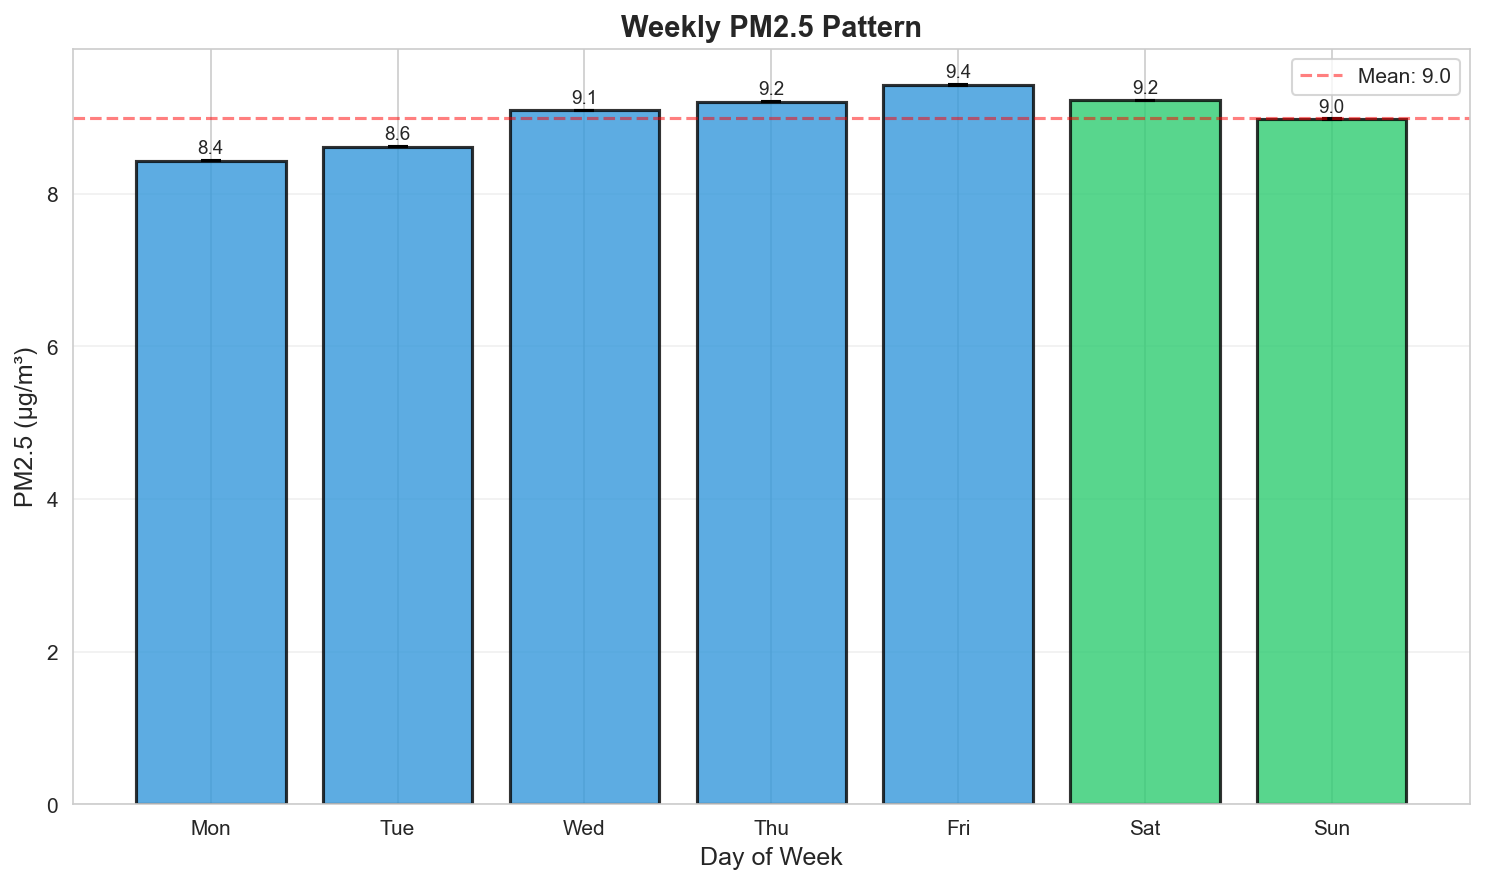

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_stats = df.groupby('day_of_week')['pm25_ugm3_mean'].agg(['mean', 'std', 'median', 'count'])
dow_stats['sem'] = dow_stats['std'] / np.sqrt(dow_stats['count'])

bars = ax.bar(dow_stats.index, dow_stats['mean'], 
              yerr=dow_stats['sem'], capsize=5,
              color=['#3498DB']*5 + ['#2ECC71']*2,
              edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('Weekly PM2.5 Pattern', fontsize=14, fontweight='bold')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_names)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=dow_stats['mean'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean: {dow_stats["mean"].mean():.1f}')

for i, (bar, val) in enumerate(zip(bars, dow_stats['mean'])):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
           f'{val:.1f}', ha='center', fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig('graphs/temporal/05_weekly_pattern.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/05_weekly_pattern.png")
plt.show()

## 6. Weekday vs Weekend Comparison

Saved: graphs/temporal/06_weekday_weekend_comparison.png


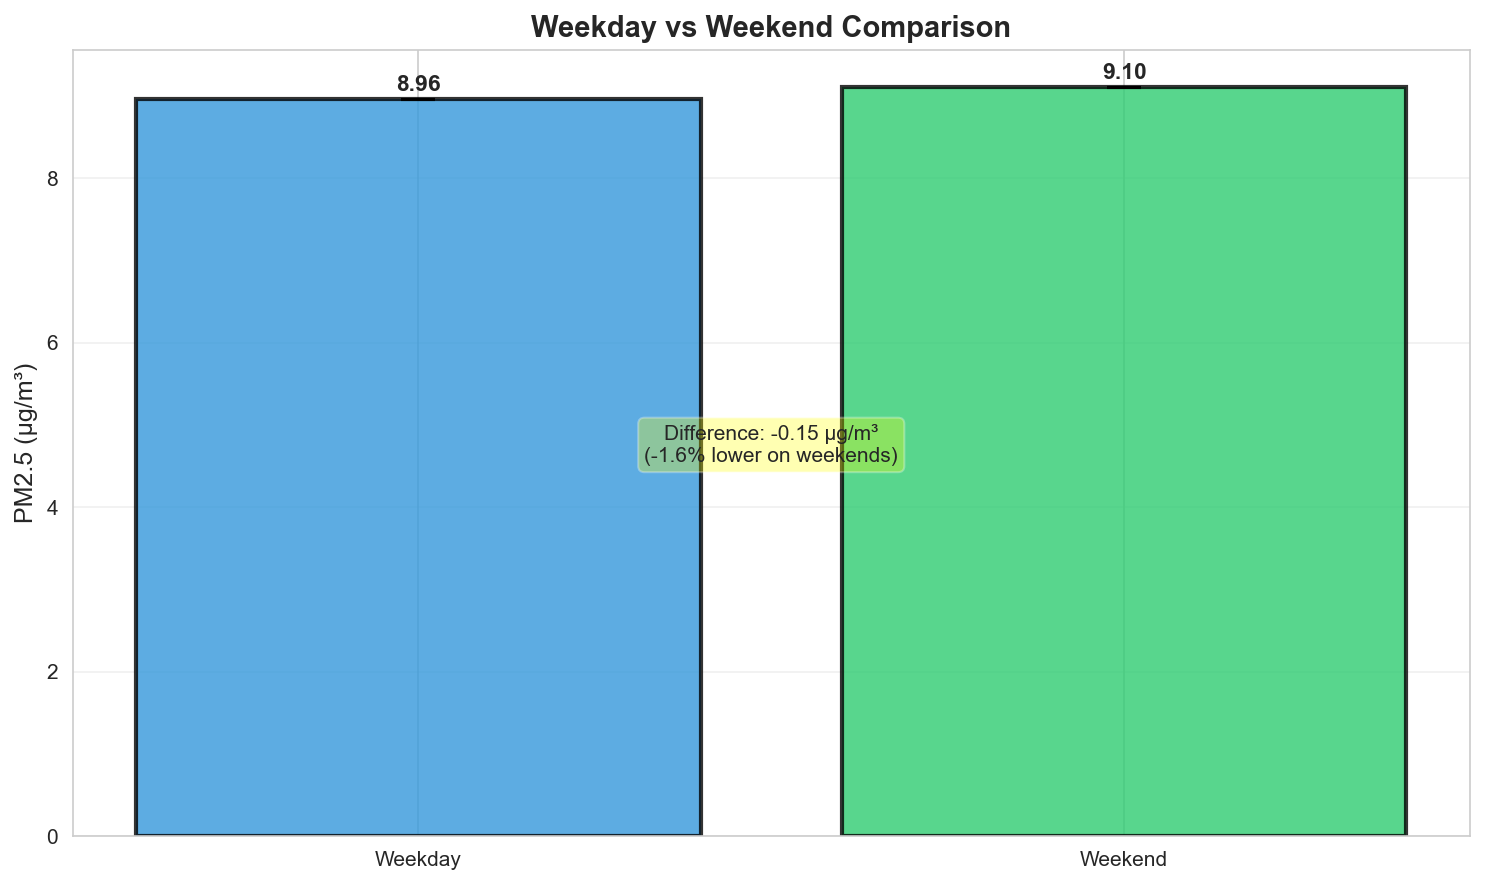

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

weekend_comparison = df.groupby('is_weekend')['pm25_ugm3_mean'].agg(['mean', 'std', 'count'])
weekend_comparison['sem'] = weekend_comparison['std'] / np.sqrt(weekend_comparison['count'])

bars = ax.bar(['Weekday', 'Weekend'], weekend_comparison['mean'],
              yerr=weekend_comparison['sem'], capsize=8,
              color=['#3498DB', '#2ECC71'], edgecolor='black', linewidth=2, alpha=0.8)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('Weekday vs Weekend Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, weekend_comparison['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
           f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

diff = weekend_comparison['mean'][0] - weekend_comparison['mean'][1]
pct_diff = diff / weekend_comparison['mean'][0] * 100
ax.text(0.5, max(weekend_comparison['mean']) * 0.5, 
       f'Difference: {diff:.2f} μg/m³\n({pct_diff:.1f}% lower on weekends)',
       ha='center', transform=ax.transData,
       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('graphs/temporal/06_weekday_weekend_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/06_weekday_weekend_comparison.png")
plt.show()

## 7. Weekly Pattern by Year

Saved: graphs/temporal/07_weekly_pattern_by_year.png


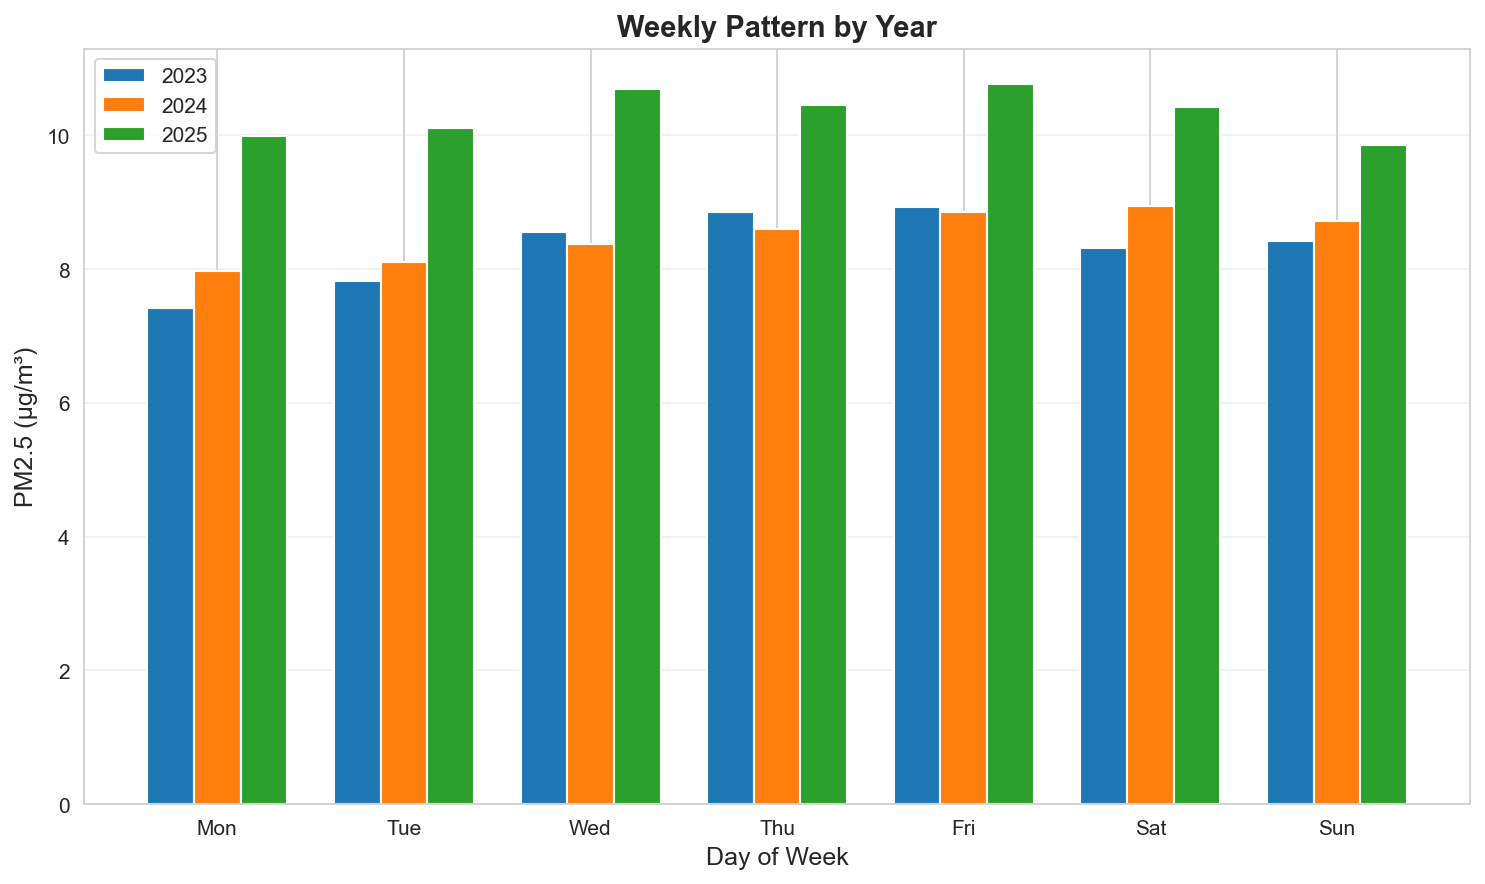

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_by_year = df.groupby(['year', 'day_of_week'])['pm25_ugm3_mean'].mean().unstack(level=0)

x = np.arange(7)
width = 0.25
for i, year in enumerate(dow_by_year.columns):
    ax.bar(x + i*width, dow_by_year[year], width, label=f'{year}')

ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('Weekly Pattern by Year', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(dow_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('graphs/temporal/07_weekly_pattern_by_year.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/07_weekly_pattern_by_year.png")
plt.show()

## 8. Monthly PM2.5 Averages

Saved: graphs/temporal/08_monthly_averages.png


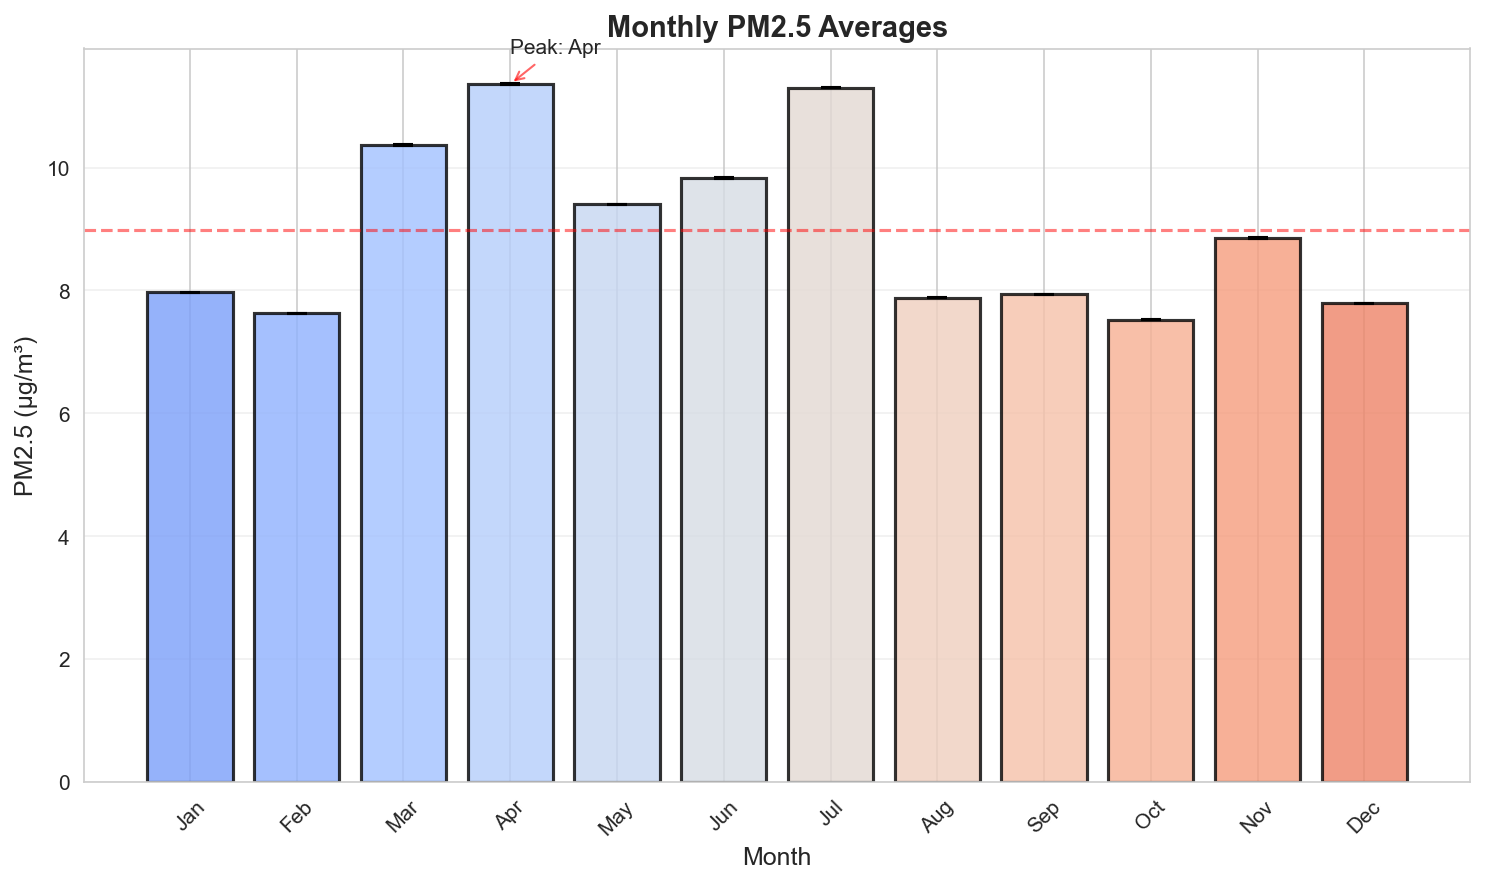

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_stats = df.groupby('month')['pm25_ugm3_mean'].agg(['mean', 'std', 'median', 'count'])
monthly_stats['sem'] = monthly_stats['std'] / np.sqrt(monthly_stats['count'])

bars = ax.bar(monthly_stats.index, monthly_stats['mean'],
              yerr=monthly_stats['sem'], capsize=5,
              color=plt.cm.coolwarm(np.linspace(0.2, 0.8, 12)),
              edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('Monthly PM2.5 Averages', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=monthly_stats['mean'].mean(), color='red', linestyle='--', alpha=0.5)

peak_month = monthly_stats['mean'].idxmax()
low_month = monthly_stats['mean'].idxmin()
ax.annotate(f'Peak: {month_names[peak_month-1]}', xy=(peak_month, monthly_stats.loc[peak_month, 'mean']),
           xytext=(peak_month, monthly_stats.loc[peak_month, 'mean'] + 0.5),
           arrowprops=dict(arrowstyle='->', color='red', alpha=0.6))

plt.tight_layout()
plt.savefig('graphs/temporal/08_monthly_averages.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/08_monthly_averages.png")
plt.show()

## 9. Seasonal PM2.5 Patterns

Saved: graphs/temporal/09_seasonal_patterns.png


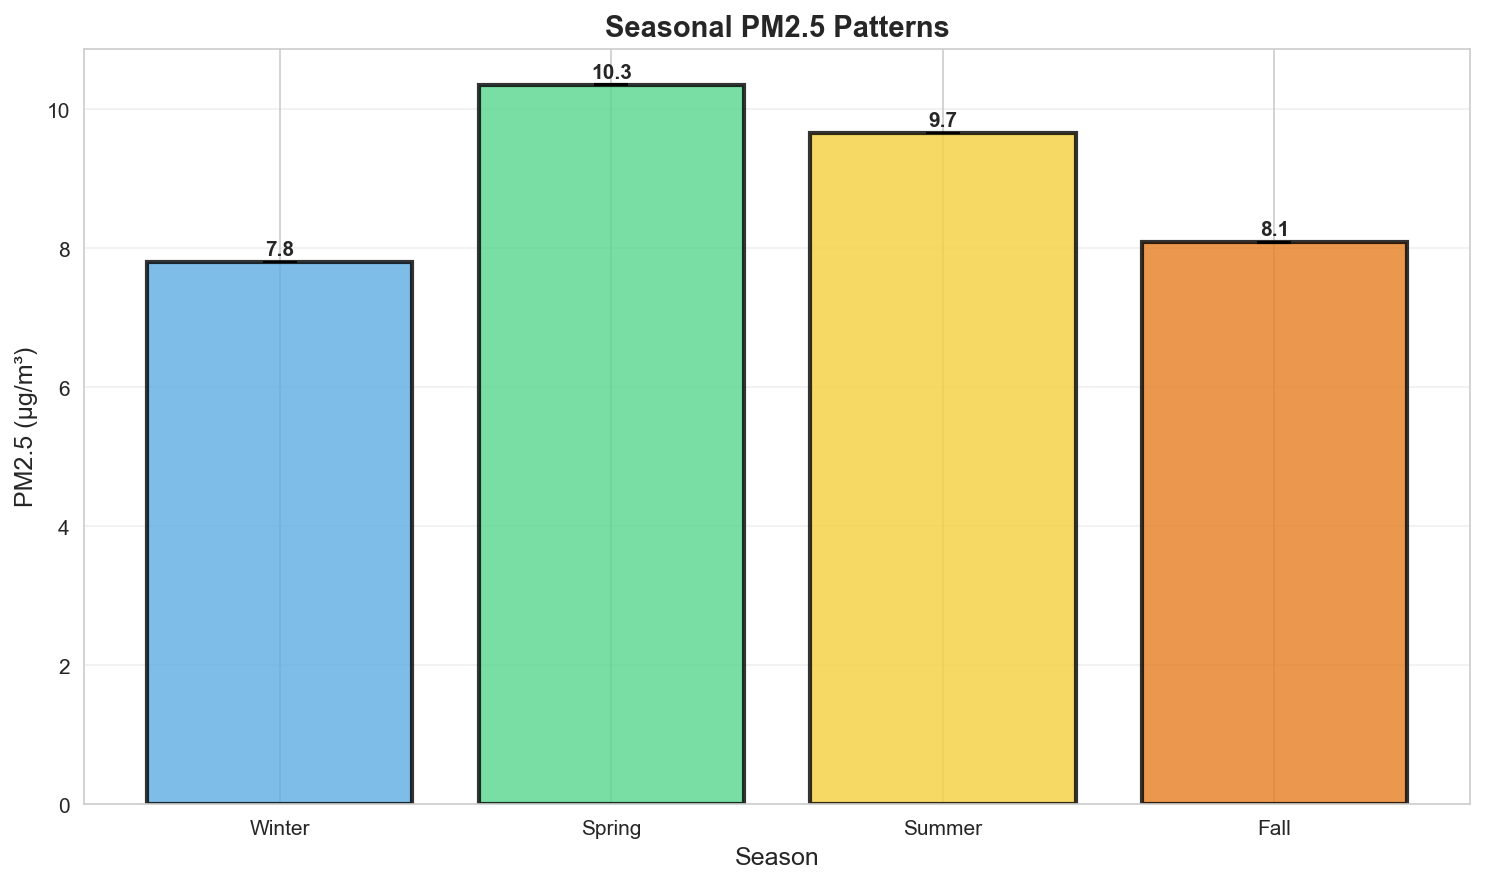

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

df['season'] = df['month'].map(lambda x: 'Winter' if x in [12, 1, 2]
                               else 'Spring' if x in [3, 4, 5]
                               else 'Summer' if x in [6, 7, 8]
                               else 'Fall')
season_stats = df.groupby('season')['pm25_ugm3_mean'].agg(['mean', 'std', 'count'])
season_stats['sem'] = season_stats['std'] / np.sqrt(season_stats['count'])
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_stats = season_stats.reindex(season_order)

bars = ax.bar(range(4), season_stats['mean'],
              yerr=season_stats['sem'], capsize=8,
              color=['#5DADE2', '#58D68D', '#F4D03F', '#E67E22'],
              edgecolor='black', linewidth=2, alpha=0.8)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('Seasonal PM2.5 Patterns', fontsize=14, fontweight='bold')
ax.set_xticks(range(4))
ax.set_xticklabels(season_order)
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, season_stats['mean'])):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
           f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/temporal/09_seasonal_patterns.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/09_seasonal_patterns.png")
plt.show()

## 10. Month-Hour Heatmap (JST)

Saved: graphs/temporal/10_month_hour_heatmap.png


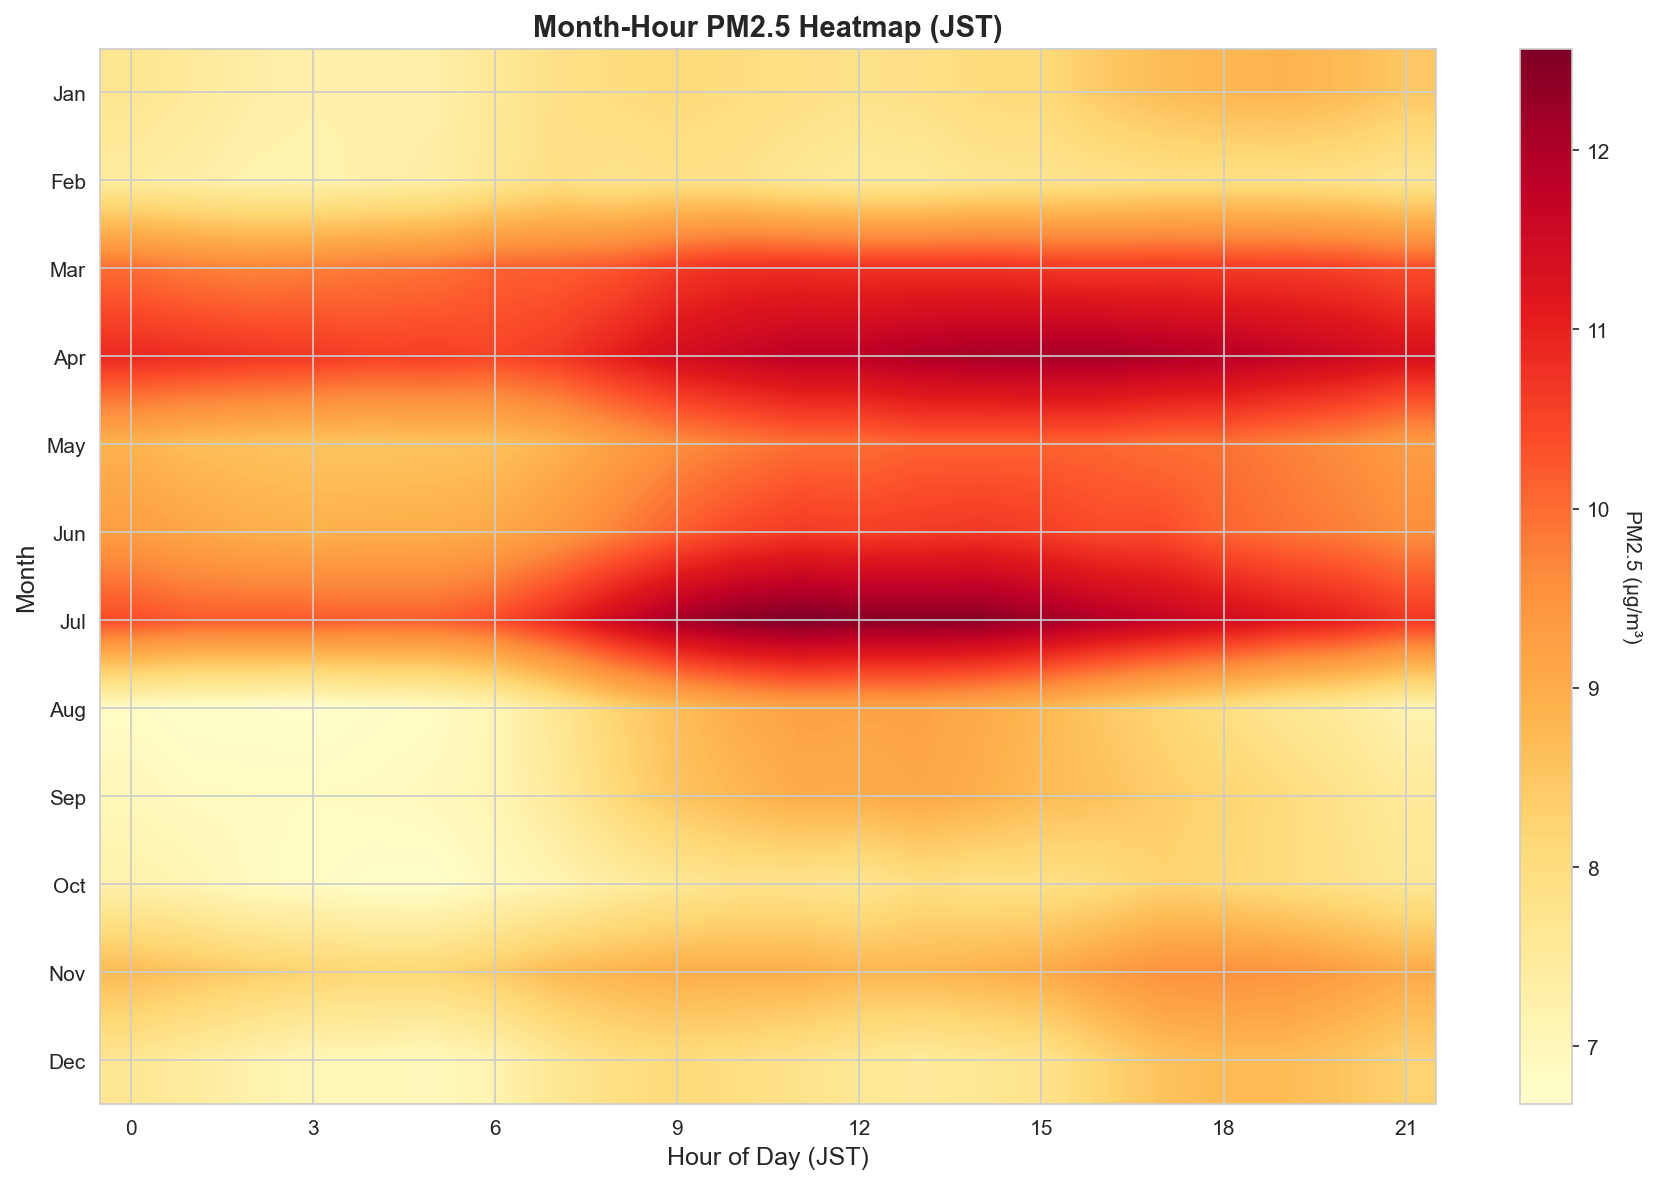

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_hour_matrix = df.groupby(['month', 'hour'])['pm25_ugm3_mean'].mean().unstack()

im = ax.imshow(month_hour_matrix, aspect='auto', cmap='YlOrRd', interpolation='bilinear')
ax.set_xlabel('Hour of Day (JST)', fontsize=12)
ax.set_ylabel('Month', fontsize=12)
ax.set_title('Month-Hour PM2.5 Heatmap (JST)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24, 3))
ax.set_yticks(range(12))
ax.set_yticklabels(month_names)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('PM2.5 (μg/m³)', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('graphs/temporal/10_month_hour_heatmap.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/10_month_hour_heatmap.png")
plt.show()

## 11. Long-term Trend with Moving Averages

Saved: graphs/temporal/11_longterm_trend_ma.png


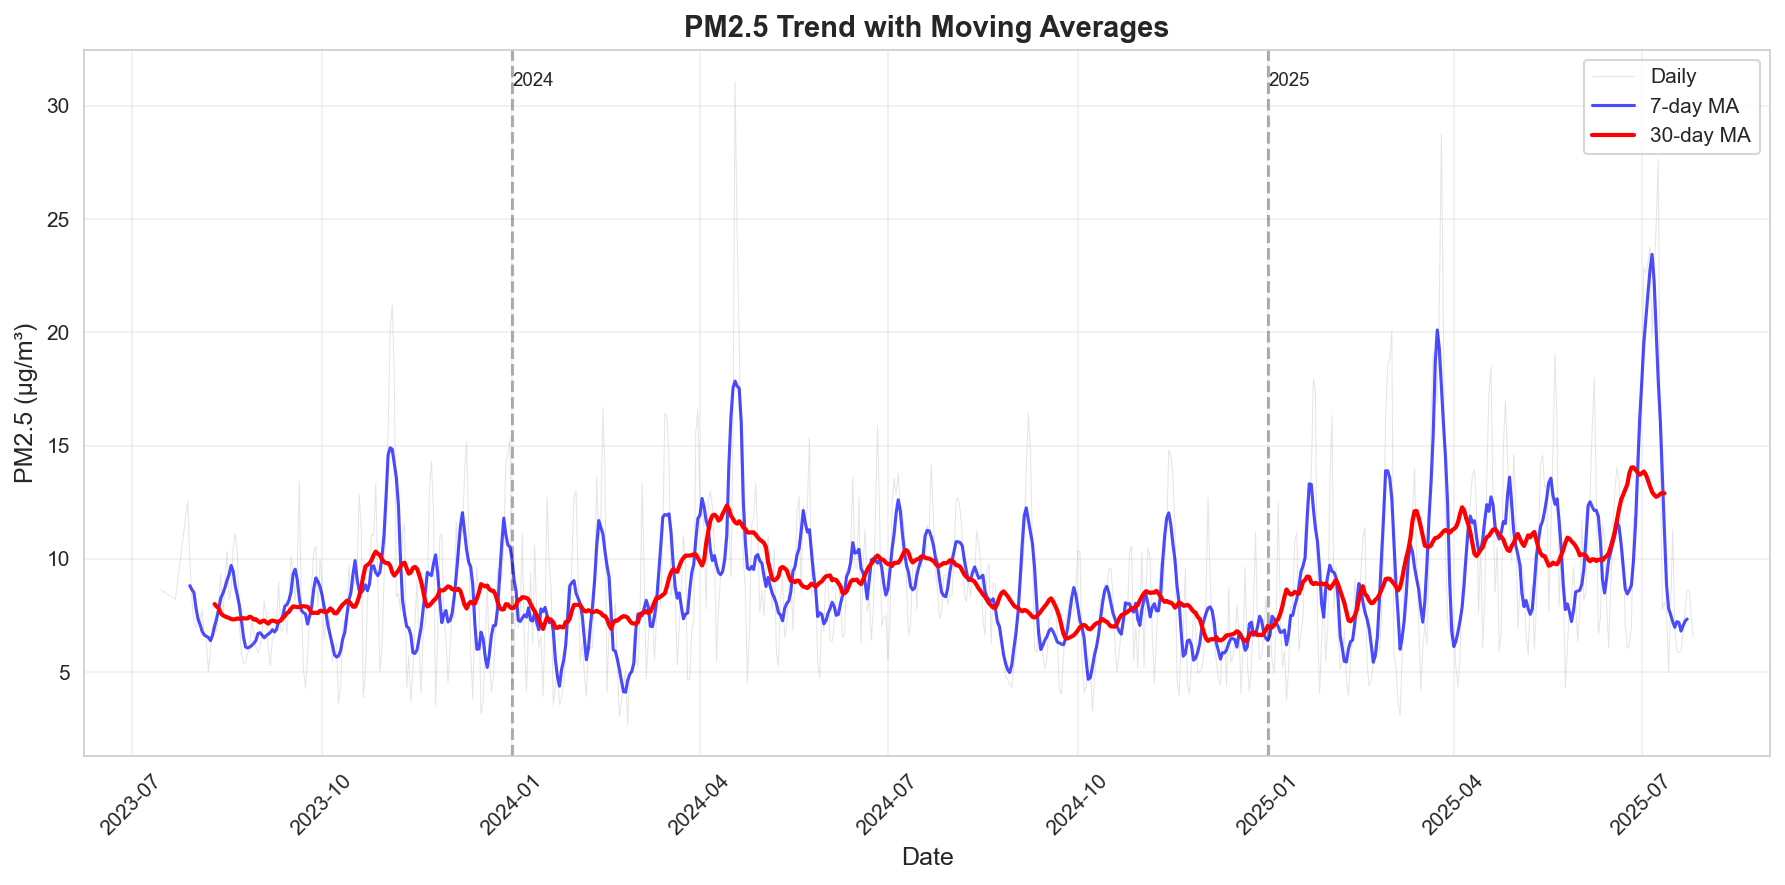

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

daily_avg = df.groupby('date')['pm25_ugm3_mean'].mean()
rolling_7d = daily_avg.rolling(window=7, center=True).mean()
rolling_30d = daily_avg.rolling(window=30, center=True).mean()

ax.plot(daily_avg.index, daily_avg.values, alpha=0.2, linewidth=0.5, color='gray', label='Daily')
ax.plot(rolling_7d.index, rolling_7d.values, linewidth=1.5, color='blue', label='7-day MA', alpha=0.7)
ax.plot(rolling_30d.index, rolling_30d.values, linewidth=2, color='red', label='30-day MA')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('PM2.5 Trend with Moving Averages', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=45)

for year in [2024, 2025]:
    year_start = pd.Timestamp(f'{year}-01-01')
    if year_start in daily_avg.index:
        ax.axvline(x=year_start, color='black', linestyle='--', alpha=0.3)
        ax.text(year_start, ax.get_ylim()[1]*0.95, str(year), fontsize=9)

plt.tight_layout()
plt.savefig('graphs/temporal/11_longterm_trend_ma.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/11_longterm_trend_ma.png")
plt.show()

## 12. Yearly Average PM2.5

Saved: graphs/temporal/12_yearly_average.png


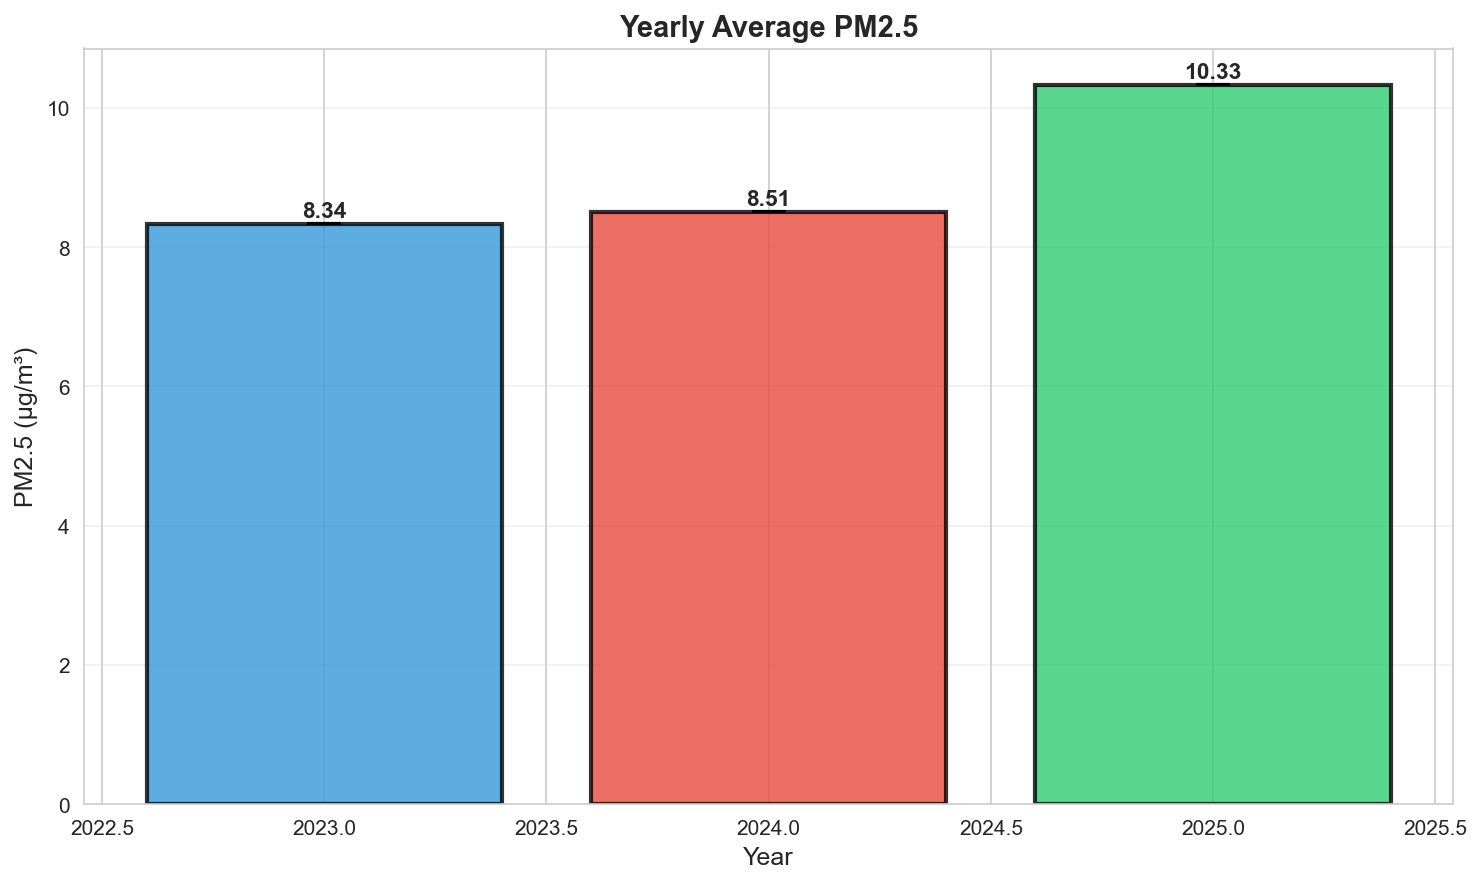

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

yearly_avg = df.groupby('year')['pm25_ugm3_mean'].agg(['mean', 'std', 'count'])
yearly_avg['sem'] = yearly_avg['std'] / np.sqrt(yearly_avg['count'])

bars = ax.bar(yearly_avg.index, yearly_avg['mean'],
              yerr=yearly_avg['sem'], capsize=8,
              color=['#3498DB', '#E74C3C', '#2ECC71'],
              edgecolor='black', linewidth=2, alpha=0.8)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('Yearly Average PM2.5', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, yearly_avg['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
           f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/temporal/12_yearly_average.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/12_yearly_average.png")
plt.show()

## 13. PM2.5 Percentile Bands

Saved: graphs/temporal/13_percentile_bands.png


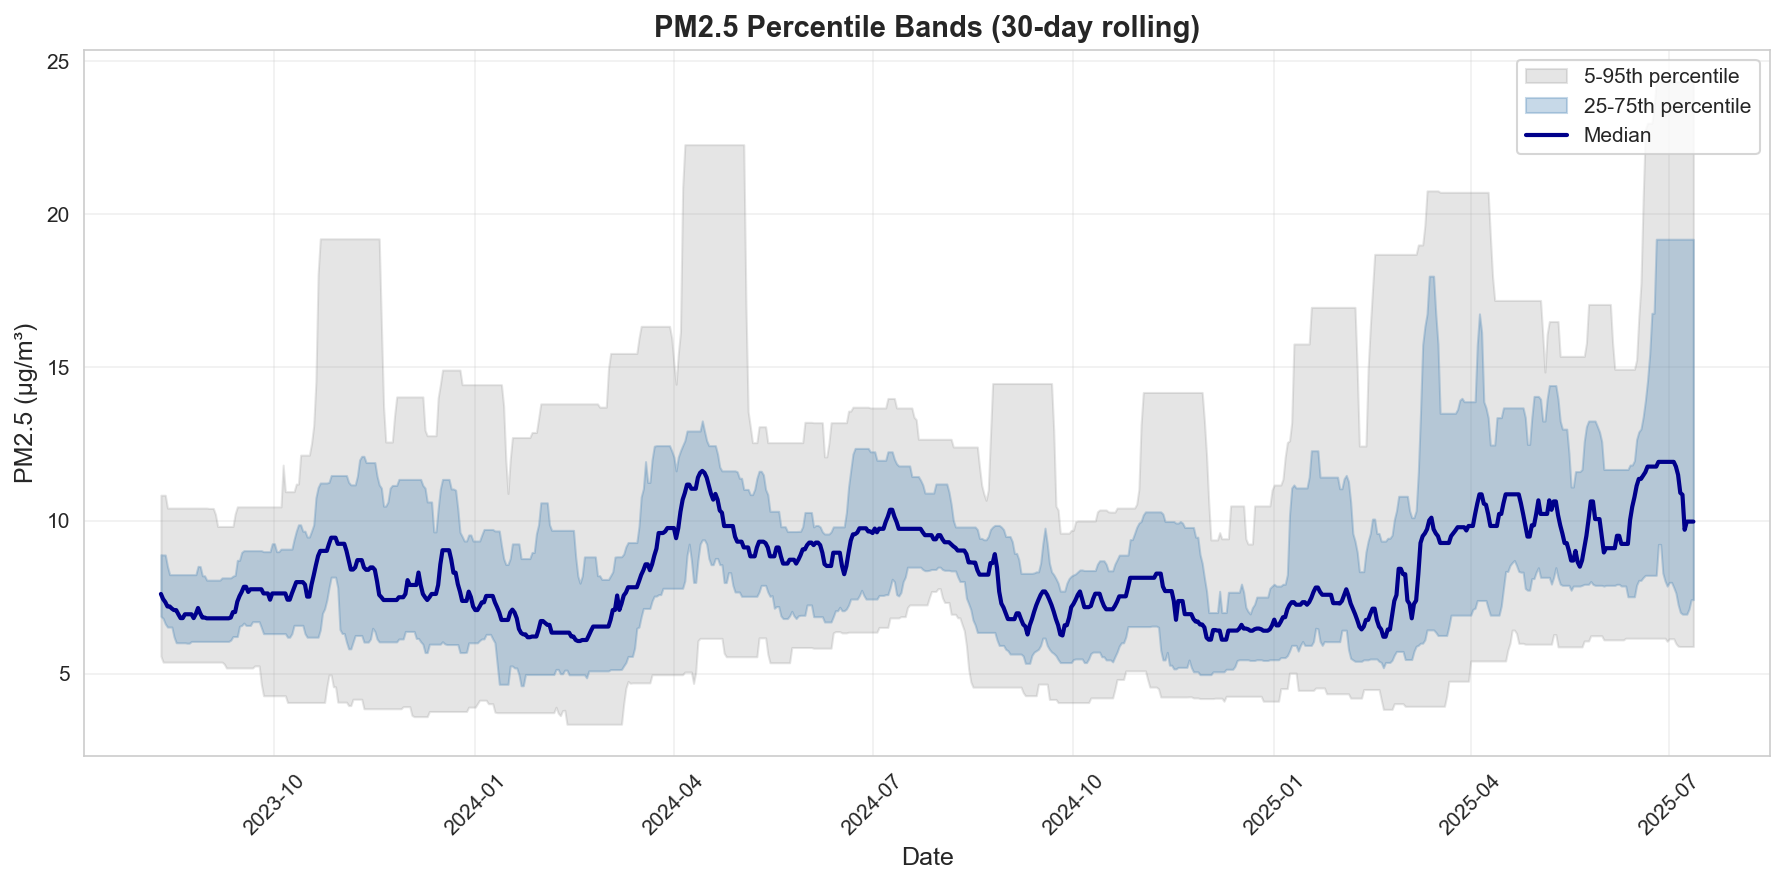

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

daily_avg = df.groupby('date')['pm25_ugm3_mean'].mean()
q05 = daily_avg.rolling(window=30, center=True).quantile(0.05)
q25 = daily_avg.rolling(window=30, center=True).quantile(0.25)
q50 = daily_avg.rolling(window=30, center=True).quantile(0.50)
q75 = daily_avg.rolling(window=30, center=True).quantile(0.75)
q95 = daily_avg.rolling(window=30, center=True).quantile(0.95)

ax.fill_between(q50.index, q05, q95, alpha=0.2, color='gray', label='5-95th percentile')
ax.fill_between(q50.index, q25, q75, alpha=0.3, color='steelblue', label='25-75th percentile')
ax.plot(q50.index, q50, linewidth=2, color='darkblue', label='Median')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('PM2.5 Percentile Bands (30-day rolling)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('graphs/temporal/13_percentile_bands.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/13_percentile_bands.png")
plt.show()

## 14. Monthly WHO Exceedance Rate

Saved: graphs/temporal/14_who_exceedance_rate.png


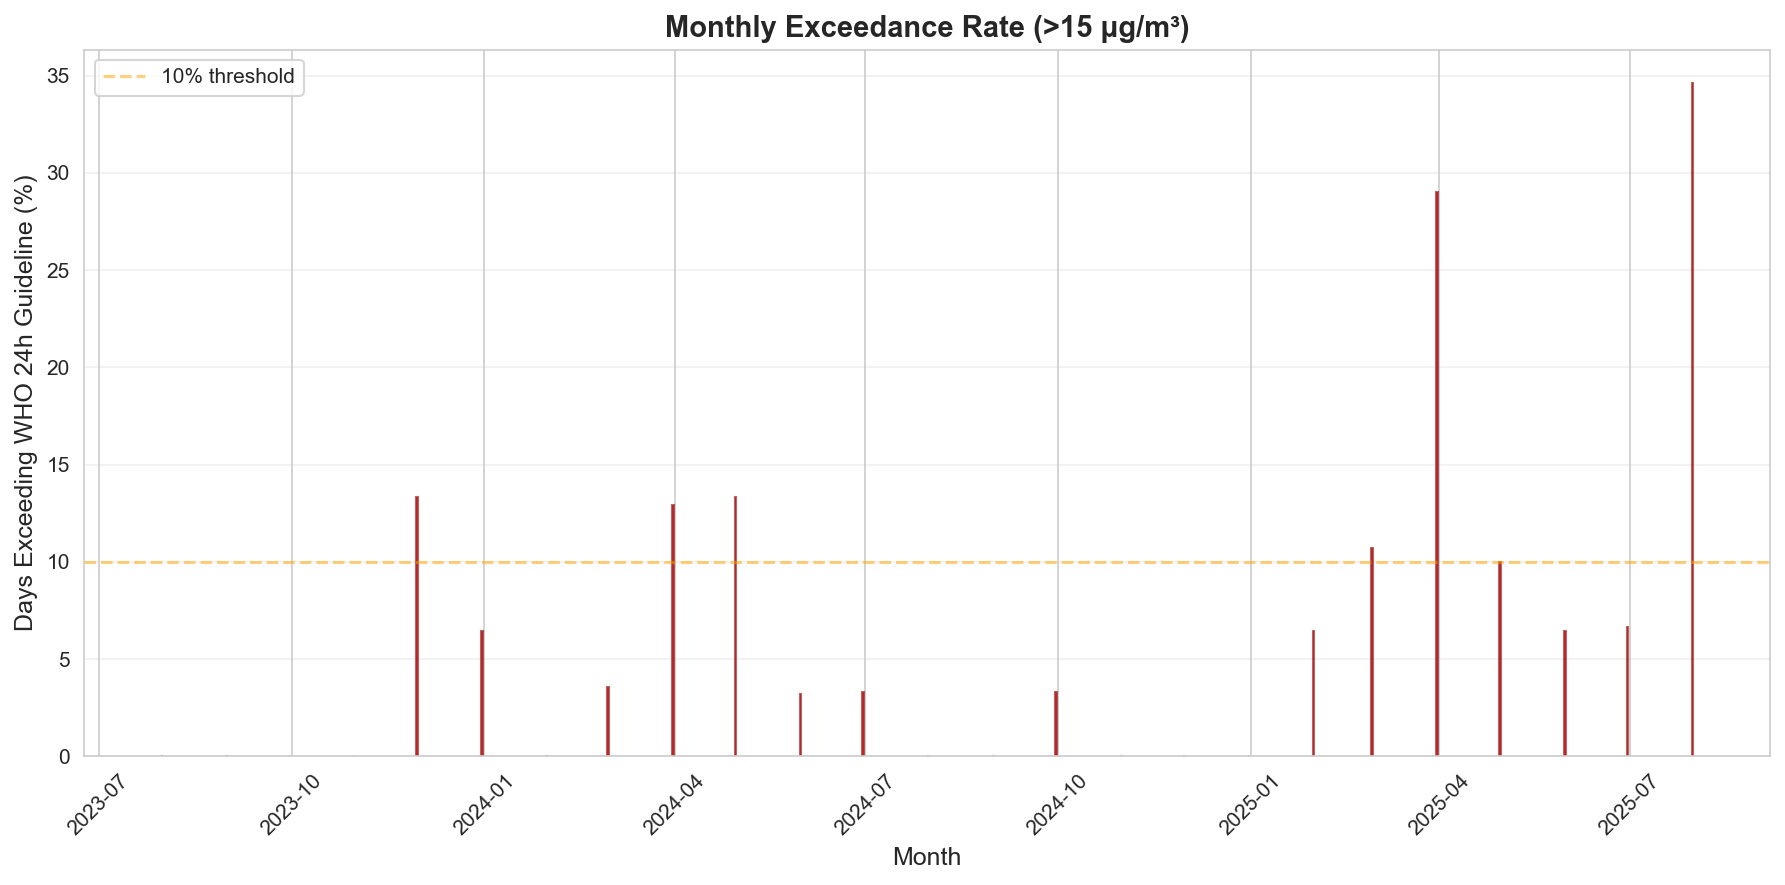

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

daily_avg = df.groupby('date')['pm25_ugm3_mean'].mean()
threshold = 15
exceedance = daily_avg > threshold
exceedance_series = pd.Series(exceedance.values, index=pd.DatetimeIndex(daily_avg.index))
monthly_exceedance = exceedance_series.resample('M').mean() * 100

ax.bar(monthly_exceedance.index, monthly_exceedance.values, 
       color='red', alpha=0.6, edgecolor='darkred', linewidth=1)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Days Exceeding WHO 24h Guideline (%)', fontsize=12)
ax.set_title(f'Monthly Exceedance Rate (>{threshold} μg/m³)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=10, color='orange', linestyle='--', alpha=0.5, label='10% threshold')
ax.legend()

plt.tight_layout()
plt.savefig('graphs/temporal/14_who_exceedance_rate.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/temporal/14_who_exceedance_rate.png")
plt.show()

## Summary - All Individual Graphs Generated

In [17]:
print("="*70)
print("INDIVIDUAL TEMPORAL PATTERN GRAPHS GENERATED")
print("="*70)
print("\n📊 DAILY PATTERNS:")
print("  ✓ 01_daily_24hour_cycle.png")
print("  ✓ 02_weekday_vs_weekend_hourly.png")
print("  ✓ 03_diurnal_by_year.png")
print("  ✓ 04_pm25_vs_traffic_hourly.png")

print("\n📅 WEEKLY PATTERNS:")
print("  ✓ 05_weekly_pattern.png")
print("  ✓ 06_weekday_weekend_comparison.png")
print("  ✓ 07_weekly_pattern_by_year.png")

print("\n📆 MONTHLY/SEASONAL:")
print("  ✓ 08_monthly_averages.png")
print("  ✓ 09_seasonal_patterns.png")
print("  ✓ 10_month_hour_heatmap.png")

print("\n📈 LONG-TERM TRENDS:")
print("  ✓ 11_longterm_trend_ma.png")
print("  ✓ 12_yearly_average.png")
print("  ✓ 13_percentile_bands.png")
print("  ✓ 14_who_exceedance_rate.png")

print("\n" + "="*70)
print("All 14 individual temporal pattern graphs saved to graphs/temporal/")
print("Each graph can be used independently in your presentation")
print("="*70)

INDIVIDUAL TEMPORAL PATTERN GRAPHS GENERATED

📊 DAILY PATTERNS:
  ✓ 01_daily_24hour_cycle.png
  ✓ 02_weekday_vs_weekend_hourly.png
  ✓ 03_diurnal_by_year.png
  ✓ 04_pm25_vs_traffic_hourly.png

📅 WEEKLY PATTERNS:
  ✓ 05_weekly_pattern.png
  ✓ 06_weekday_weekend_comparison.png
  ✓ 07_weekly_pattern_by_year.png

📆 MONTHLY/SEASONAL:
  ✓ 08_monthly_averages.png
  ✓ 09_seasonal_patterns.png
  ✓ 10_month_hour_heatmap.png

📈 LONG-TERM TRENDS:
  ✓ 11_longterm_trend_ma.png
  ✓ 12_yearly_average.png
  ✓ 13_percentile_bands.png
  ✓ 14_who_exceedance_rate.png

All 14 individual temporal pattern graphs saved to graphs/temporal/
Each graph can be used independently in your presentation
